<a href="https://colab.research.google.com/github/Sidharth-1506/Data-Science-Lab-Work/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Required Libraries
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Class imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

In [2]:
# Load the Dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [3]:
# Basic Overview of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Shape of Dataset
df.shape

(7043, 21)

In [5]:
# Data Types & Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistical Summary
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
# Checking Unique Values
for col in df.columns:
    print(col, df[col].nunique())

customerID 7043
gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 73
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1585
TotalCharges 6531
Churn 2


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
# Handle Missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [11]:
# Drop Irrelevant column
df.drop('customerID', axis=1, inplace=True)

In [12]:
# Convert Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

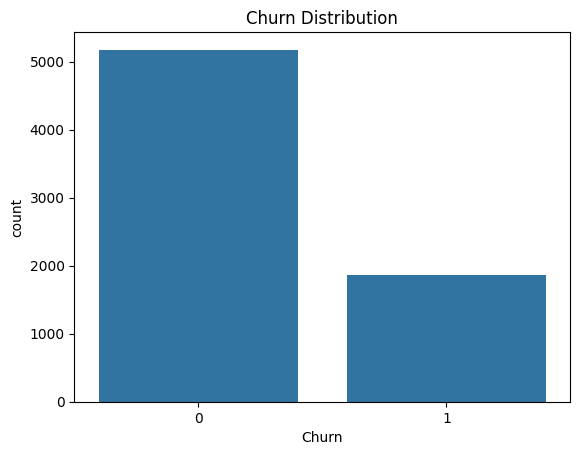

In [13]:
# Checking Class Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

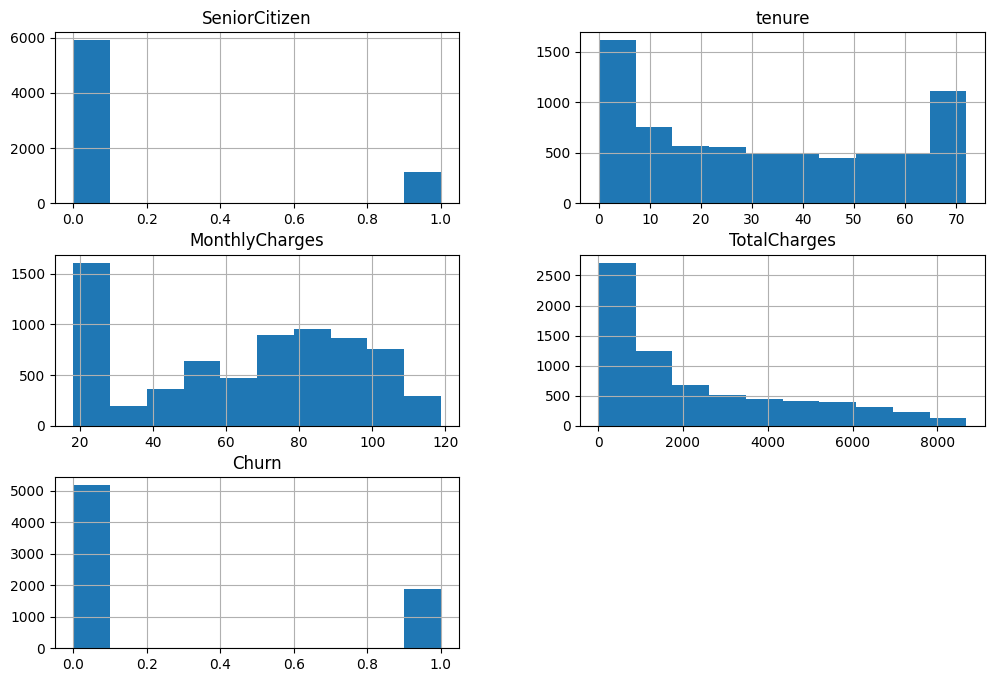

In [14]:
# Histograms (Numerical Distribution)
df.hist(figsize=(12,8))
plt.show()

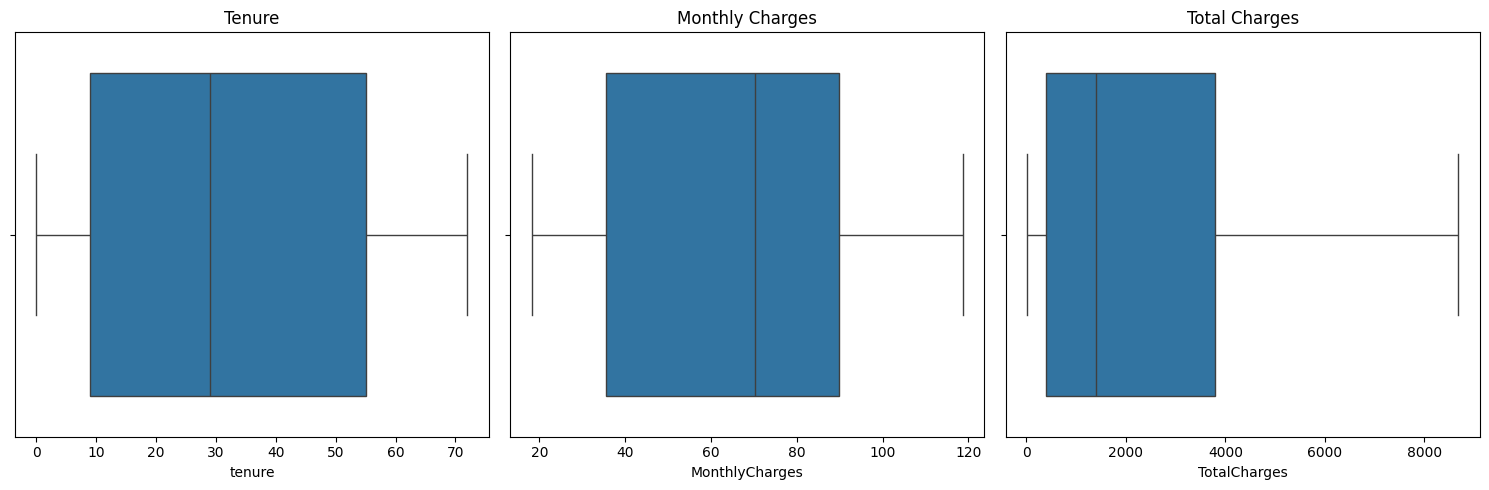

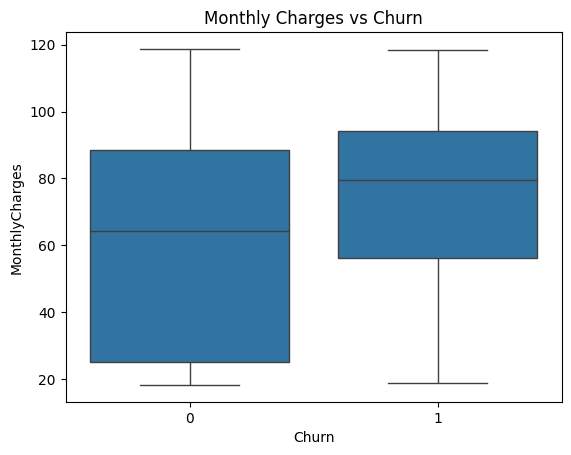

In [15]:
# Boxplots (Outlier Detection)
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(x=df['tenure'], ax=axes[0])
axes[0].set_title("Tenure")

sns.boxplot(x=df['MonthlyCharges'], ax=axes[1])
axes[1].set_title("Monthly Charges")

sns.boxplot(x=df['TotalCharges'], ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout() # This tight layout applies to the first figure
plt.show() # This shows the first figure

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

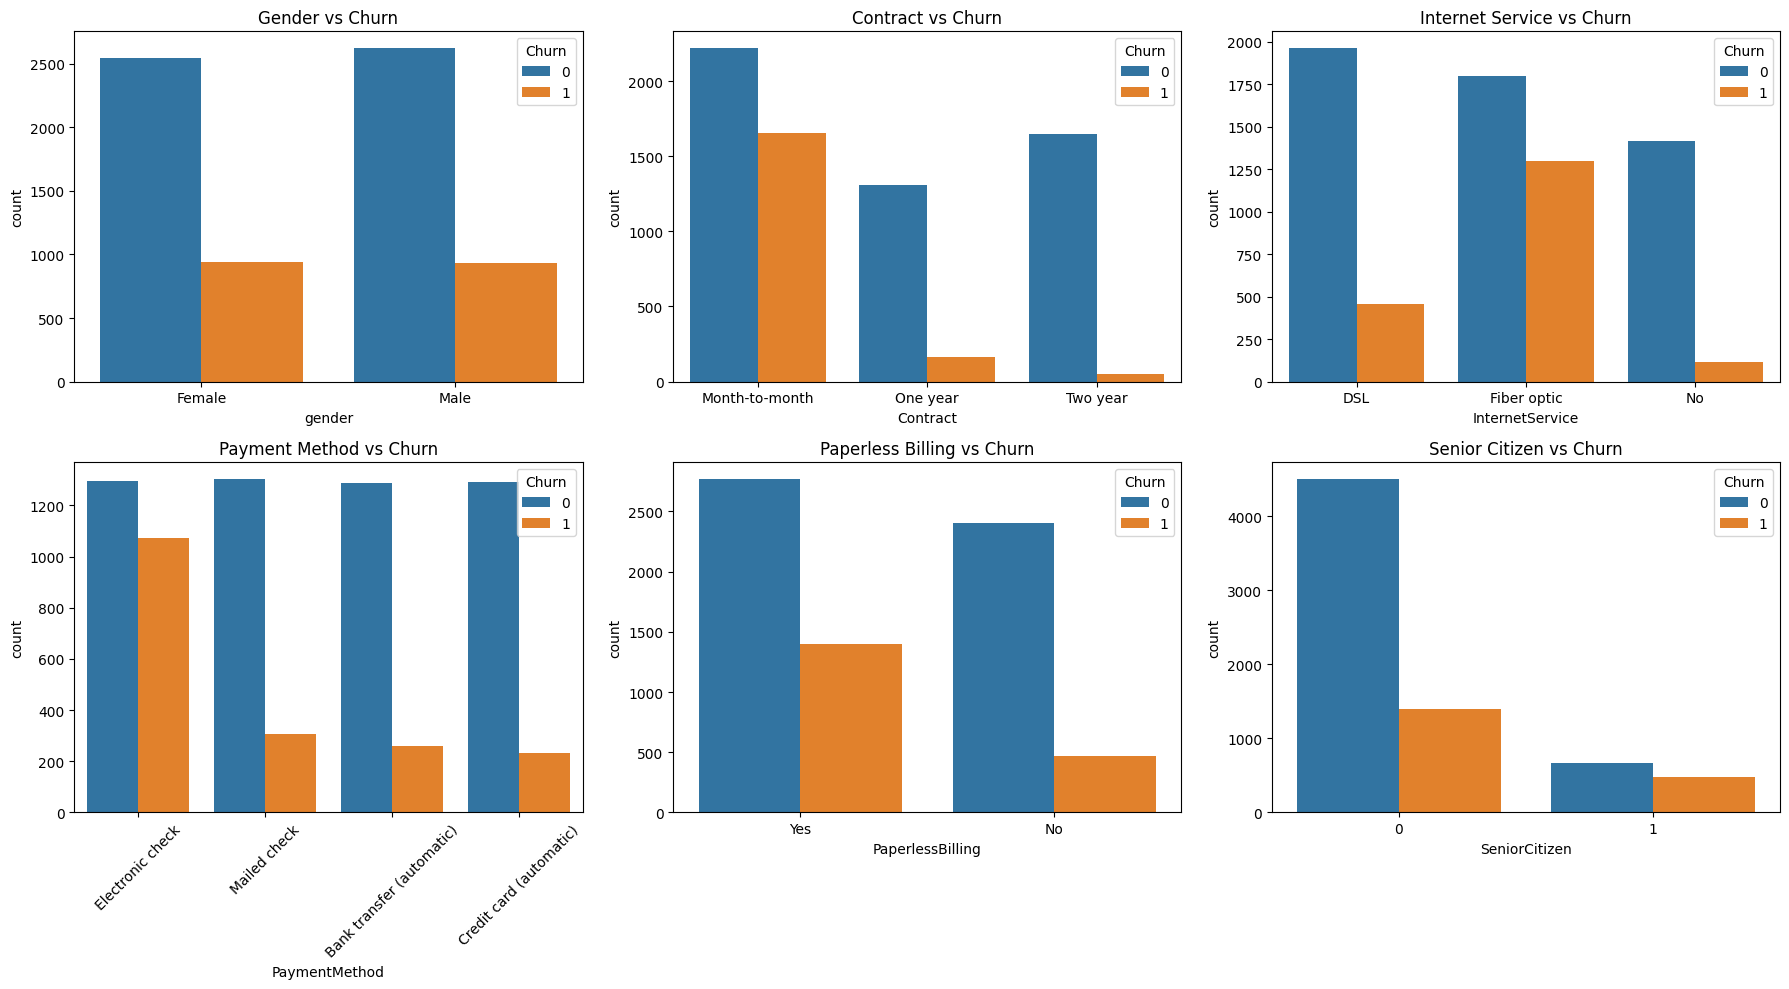

In [16]:
# -----------------------------------------
# Bar Charts: Categorical Features vs Churn
# -----------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Gender
sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0,0])
axes[0,0].set_title("Gender vs Churn")

# Contract
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0,1])
axes[0,1].set_title("Contract vs Churn")

# Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0,2])
axes[0,2].set_title("Internet Service vs Churn")

# Payment Method
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1,0])
axes[1,0].set_title("Payment Method vs Churn")
axes[1,0].tick_params(axis='x', rotation=45)

# Paperless Billing
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title("Paperless Billing vs Churn")

# Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[1,2])
axes[1,2].set_title("Senior Citizen vs Churn")

plt.tight_layout()
plt.show()

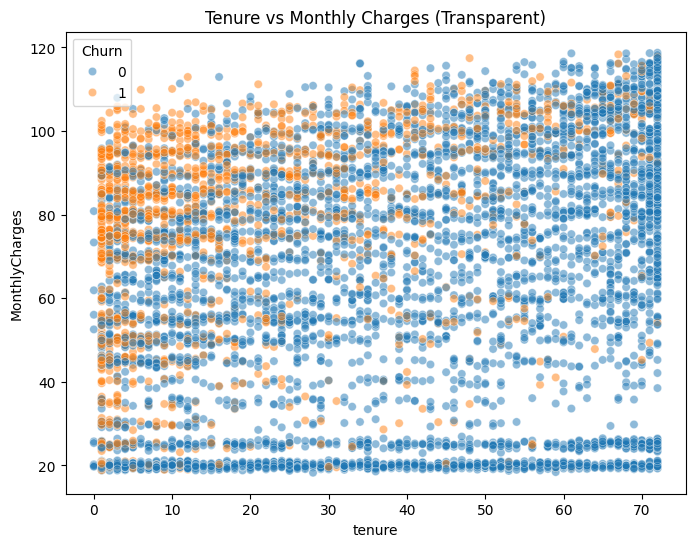

In [17]:
# Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5)
plt.title("Tenure vs Monthly Charges (Transparent)")
plt.show()

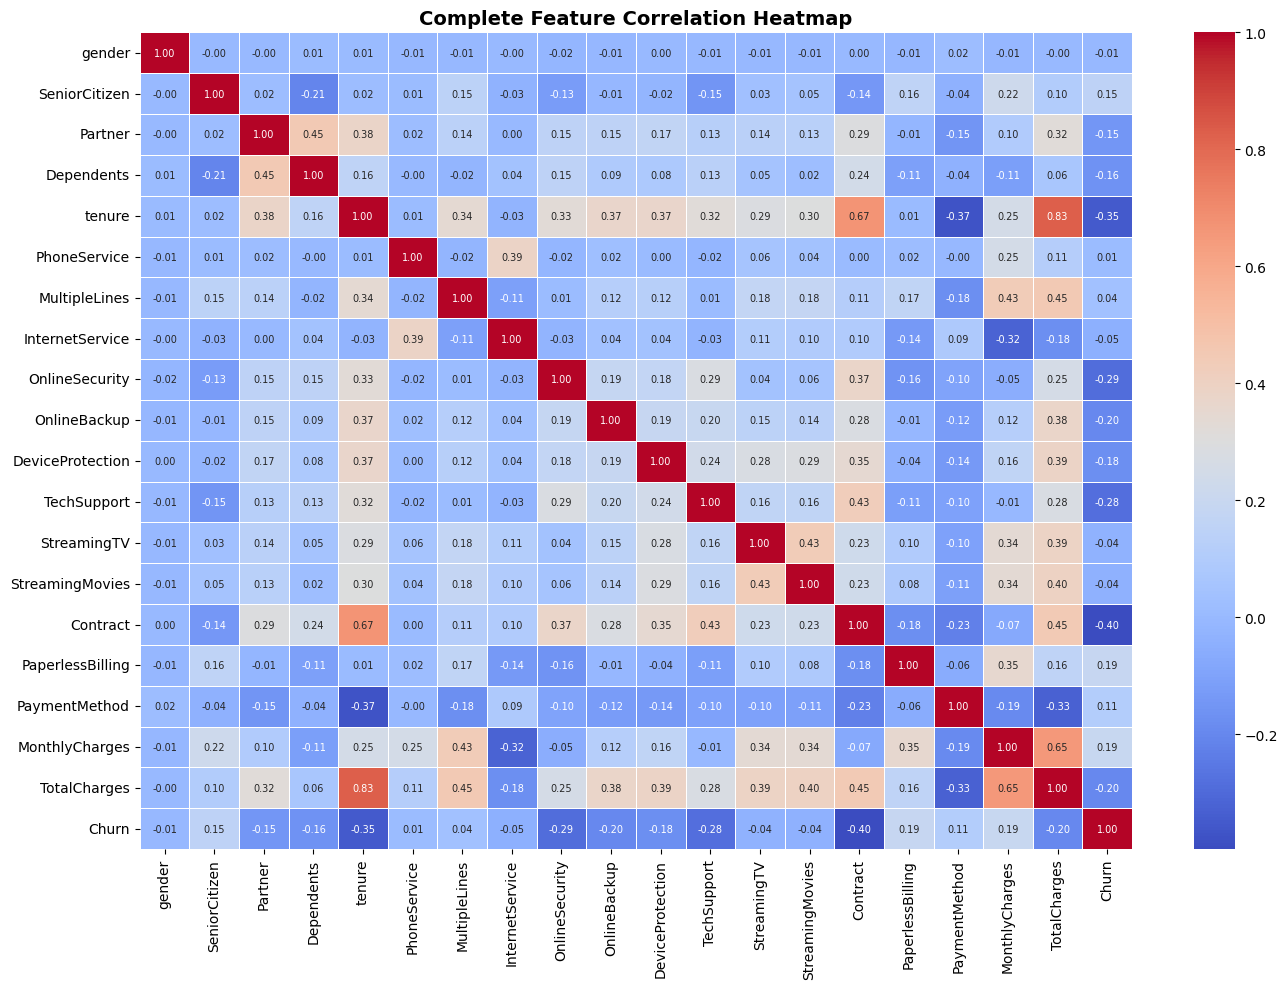

In [18]:

# Complete Correlation Heatmap

# Create a copy for encoding
df_corr = df.copy()

# Encode categorical variables
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

# Compute correlation matrix
corr = df_corr.corr()

# Plot full heatmap
plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":7}
)

plt.title("Complete Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

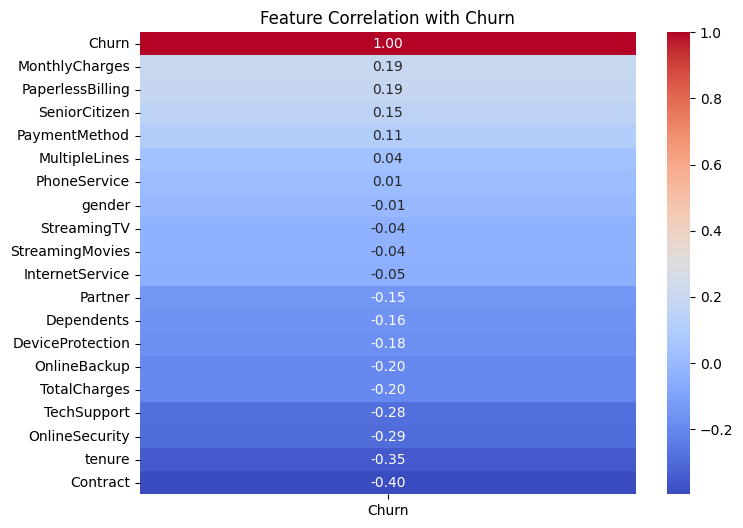

In [19]:
# Correlation with churn only
churn_corr = corr['Churn'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.heatmap(
    churn_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation with Churn")
plt.show()

In [20]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

In [21]:
# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical Columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [22]:
# Create tenure groups (categorical feature)
X['tenure_group'] = pd.cut(X['tenure'], bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [23]:
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [24]:
# Split data (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# Scale numerical features
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [26]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

Model Training and Evaluation

In [27]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [28]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [29]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [30]:
# ANN (MLP Classifier)
ann = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)
y_prob_ann = ann.predict_proba(X_test)[:,1]

In [31]:
def evaluate_model(y_test, y_pred, y_prob):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [32]:
print("Logistic Regression")
evaluate_model(y_test, y_pred_lr, y_prob_lr)

print("\nDecision Tree")
evaluate_model(y_test, y_pred_dt, y_prob_dt)

print("\nRandom Forest")
evaluate_model(y_test, y_pred_rf, y_prob_rf)

print("\nANN")
evaluate_model(y_test, y_pred_ann, y_prob_ann)

Logistic Regression
Accuracy: 0.752306600425834
Precision: 0.5250501002004008
Recall: 0.7005347593582888
F1 Score: 0.6002290950744559
ROC-AUC: 0.8212534552688007

Confusion Matrix:
 [[798 237]
 [112 262]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.70      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.75      0.76      1409


Decision Tree
Accuracy: 0.709013484740951
Precision: 0.4594594594594595
Recall: 0.5454545454545454
F1 Score: 0.49877750611246946
ROC-AUC: 0.6586194425069105

Confusion Matrix:
 [[795 240]
 [170 204]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.80      1035
           1       0.46      0.55      0.50       374

    accuracy                           0.71      1409

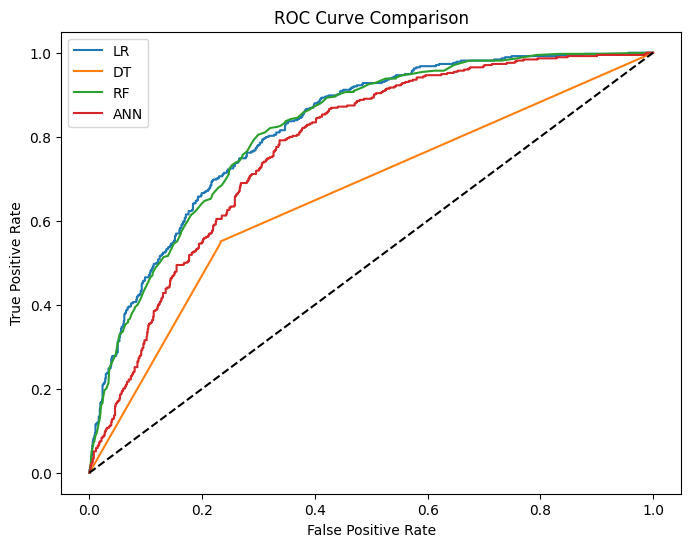

In [33]:
# ROC Curve
plt.figure(figsize=(8,6))

for name, y_prob in zip(
    ["LR", "DT", "RF", "ANN"],
    [y_prob_lr, y_prob_dt, y_prob_rf, y_prob_ann]
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [34]:
results = []

def store_results(name, y_test, y_pred, y_prob):
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

store_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
store_results("Decision Tree", y_test, y_pred_dt, y_prob_dt)
store_results("Random Forest", y_test, y_pred_rf, y_prob_rf)
store_results("ANN", y_test, y_pred_ann, y_prob_ann)

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752307,0.525050,0.700535,0.600229,0.821253
1,Decision Tree,0.709013,0.459459,0.545455,0.498778,0.658619
2,Random Forest,0.761533,0.544393,0.622995,0.581047,0.817278
3,ANN,0.714691,0.472222,0.636364,0.542141,0.775608
